In [1]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/SMSML/Online Retail.xlsx'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
df = pd.read_excel(DATA_PATH)

print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
# Cek missing values per kolom
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
# Persentase missing
(df.isnull().sum() / len(df) * 100).round(2)

,0
InvoiceNo,0.00
StockCode,0.00
Description,0.27
Quantity,0.00
InvoiceDate,0.00
UnitPrice,0.00
CustomerID,24.93
Country,0.00


In [9]:
# Quantity negatif (biasanya indikasi return/pembatalan)
print("Quantity negatif:", (df['Quantity'] < 0).sum())

# UnitPrice nol atau negatif (data gak valid)
print("UnitPrice <= 0:", (df['UnitPrice'] <= 0).sum())

# InvoiceNo yang diawali 'C' = cancelled order
print("Cancelled orders (InvoiceNo 'C'):", df['InvoiceNo'].astype(str).str.startswith('C').sum())

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Quantity negatif: 10624
UnitPrice <= 0: 2517
Cancelled orders (InvoiceNo 'C'): 9288
Duplicate rows: 5268


In [10]:
# Lihat contoh baris Quantity negatif
df[df['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


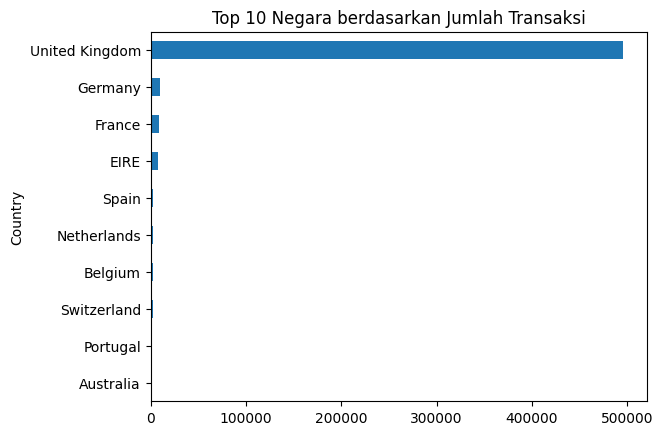

In [11]:
import matplotlib.pyplot as plt

# Top 10 negara berdasarkan jumlah transaksi
df['Country'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Negara berdasarkan Jumlah Transaksi')
plt.gca().invert_yaxis()
plt.show()

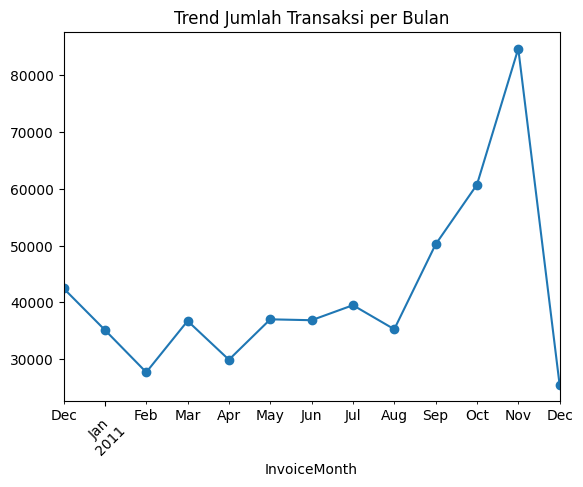

In [12]:
# Trend jumlah transaksi per bulan
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df.groupby('InvoiceMonth').size().plot(kind='line', marker='o')
plt.title('Trend Jumlah Transaksi per Bulan')
plt.xticks(rotation=45)
plt.show()

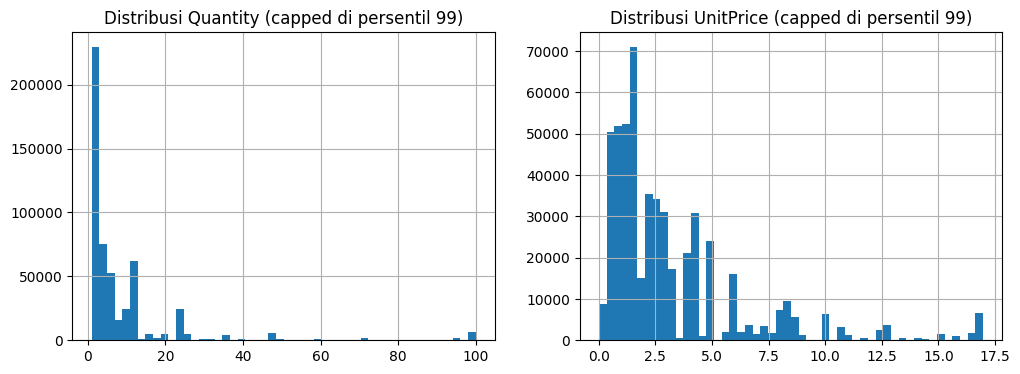

In [13]:
# Distribusi Quantity dan UnitPrice (hanya data valid, qty > 0 & price > 0)
valid = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
valid['Quantity'].clip(upper=valid['Quantity'].quantile(0.99)).hist(bins=50, ax=axes[0])
axes[0].set_title('Distribusi Quantity (capped di persentil 99)')

valid['UnitPrice'].clip(upper=valid['UnitPrice'].quantile(0.99)).hist(bins=50, ax=axes[1])
axes[1].set_title('Distribusi UnitPrice (capped di persentil 99)')
plt.show()

In [14]:
# Filter data valid saja
df_clean = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0) &
    (df['CustomerID'].notnull())
].copy()

# Drop duplicate
df_clean = df_clean.drop_duplicates()

# Pastikan tidak ada invoice cancelled ('C') yang kebawa
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# CustomerID jadi integer (sekarang float karena ada NaN sebelumnya)
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# Tambah kolom total harga per baris transaksi
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("Sebelum cleaning:", df.shape)
print("Setelah cleaning:", df_clean.shape)

Sebelum cleaning: (541909, 9)
Setelah cleaning: (392692, 10)


In [15]:
import datetime as dt

# Titik referensi waktu: 1 hari setelah transaksi terakhir di dataset
reference_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
print("Reference date:", reference_date)

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(rfm.shape)
rfm.head()
rfm.describe()

Reference date: 2011-12-10 12:50:00
(4338, 4)


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


In [16]:
CHURN_THRESHOLD = 90  # hari

rfm['Churn'] = (rfm['Recency'] > CHURN_THRESHOLD).astype(int)

print(rfm['Churn'].value_counts())
print(rfm['Churn'].value_counts(normalize=True).round(3))

Churn
0    2889
1    1449
Name: count, dtype: int64
Churn
0    0.666
1    0.334
Name: proportion, dtype: float64


In [17]:
import numpy as np

rfm['Recency_log'] = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

rfm[['Recency_log', 'Frequency_log', 'Monetary_log']].describe()

,Recency_log,Frequency_log,Monetary_log
count,4338.000000,4338.000000,4338.000000
mean,3.830734,1.345582,6.588562
std,1.340261,0.683104,1.258438
min,0.693147,0.693147,1.558145
25%,2.944439,0.693147,5.728418
50%,3.951244,1.098612,6.506636
75%,4.962845,1.791759,7.415535
max,5.926926,5.347108,12.543284


In [18]:
from sklearn.model_selection import train_test_split

X = rfm[['Recency_log', 'Frequency_log', 'Monetary_log']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train churn ratio:", y_train.mean().round(3))
print("Test churn ratio:", y_test.mean().round(3))

Train: (3470, 3) Test: (868, 3)
Train churn ratio: 0.334
Test churn ratio: 0.334


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [20]:
import os

os.makedirs('namadataset_preprocessing', exist_ok=True)

X_train_scaled.to_csv('namadataset_preprocessing/X_train.csv', index=False)
X_test_scaled.to_csv('namadataset_preprocessing/X_test.csv', index=False)
y_train.to_csv('namadataset_preprocessing/y_train.csv', index=False)
y_test.to_csv('namadataset_preprocessing/y_test.csv', index=False)

print("Tersimpan di folder namadataset_preprocessing/")

Tersimpan di folder namadataset_preprocessing/
